In [3]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3
import bisect
import math

from scipy import stats
from scipy.stats import norm
from statsmodels.nonparametric.kernel_regression import KernelReg
from pygam import LinearGAM, s

In [6]:
with open("results/utm15_2_num_length_30_runtimes.pkl", "rb") as f:
    utm_num_runtimes = pickle.load(f)

with open("results/bf_num_length_11_runtimes.pkl", "rb") as f:
    bf_num_runtimes = pickle.load(f)

with open("results/rule110_num_length_24_runtimes.pkl", "rb") as f:
    rule110_num_runtimes = pickle.load(f)

with open("results/tag_num_runtimes.pkl", "rb") as f:
    tag_num_runtimes = pickle.load(f)


In [8]:
def test_for_spikes(runtime, p, n_splines=25):
    # 1. Transform to log-log domain and sort by runtime
    log_runtime = np.log(runtime)
    log_p = np.log(p)

    order = np.argsort(log_runtime)
    x = log_runtime[order]
    y = log_p[order]

    # 2. Fit smooth mean using local linear regression or GAM splines
    # (For large n, pygam.LinearGAM or scipy.interpolate.UnivariateSpline is faster than KernelReg)
    gam_mu = LinearGAM(s(0, n_splines=n_splines)).fit(x, y)
    mu_hat = gam_mu.predict(x)
    residuals = y - mu_hat

    # 3. Fit smooth conditional variance
    gam_sigma = LinearGAM(s(0, n_splines=n_splines)).fit(x, np.log(residuals**2 + 1e-12))
    sigma_hat = np.sqrt(np.exp(gam_sigma.predict(x)))

    # 4. Standardized residuals
    z = residuals / sigma_hat

    # 5. Nonparametric check: Lag-1 autocorrelation along sorted runtime
    corr, p_val_corr = stats.pearsonr(z[:-1], z[1:])
    print(f"Lag-1 Serial Correlation: {corr:.4f} (p-value: {p_val_corr})")

    # 6. Cumulative residual cusum test
    cusum = np.cumsum(z) / np.sqrt(len(z))
    max_dev = np.max(np.abs(cusum))
    print(f"Max Cumulative Sum Deviation: {max_dev:.4f}")

    return gam_mu, gam_sigma

In [9]:
# log-log plot of runtimes against probability
utm_total_programs = np.sum(utm_num_runtimes)
utm_probabilities = utm_num_runtimes / utm_total_programs

bf_total_programs = np.sum(bf_num_runtimes)
bf_probabilities = bf_num_runtimes / bf_total_programs

rule110_total_programs = np.sum(rule110_num_runtimes)
rule110_probabilities = rule110_num_runtimes / rule110_total_programs

tag_total_programs = np.sum(tag_num_runtimes)
tag_probabilities = tag_num_runtimes / tag_total_programs


p_dict = {
    "bf": bf_probabilities,
    "rule110": rule110_probabilities,
    "utm": utm_probabilities,
    "tag": tag_probabilities,
}

names_dict = {
    "bf": "BF",
    "rule110": "Rule110",
    "utm": "UTM",
    "tag": "2-Tag"
}

domain = "utm"

runtime = np.arange(max_runtime)
p = p_dict[domain]

filter = p > 0
p = p[filter]
runtime = runtime[filter]

gam_mu, gam_sigma = test_for_spikes(runtime, p, n_splines=20)

Lag-1 Serial Correlation: 0.5632 (p-value: 0.0)
Max Cumulative Sum Deviation: 2.0480


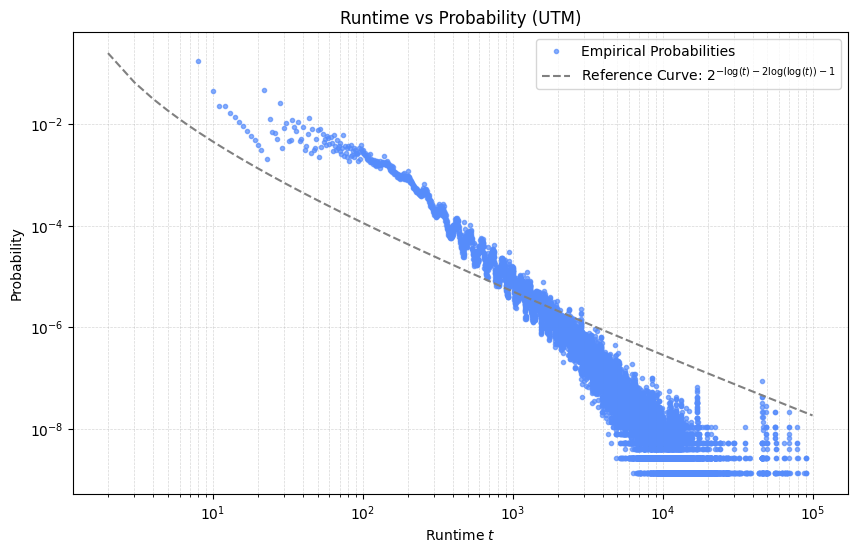

In [10]:
max_runtime = 100_000

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(runtime, p, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Empirical Probabilities")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 1)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 1}$')
plt.legend()

plt.title(f'Runtime vs Probability ({names_dict[domain]})')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)


# save plot as pdf
#plt.savefig(f"runtime_vs_probability_{domain}.pdf")

plt.show()

KS $p = 1.05e-279$


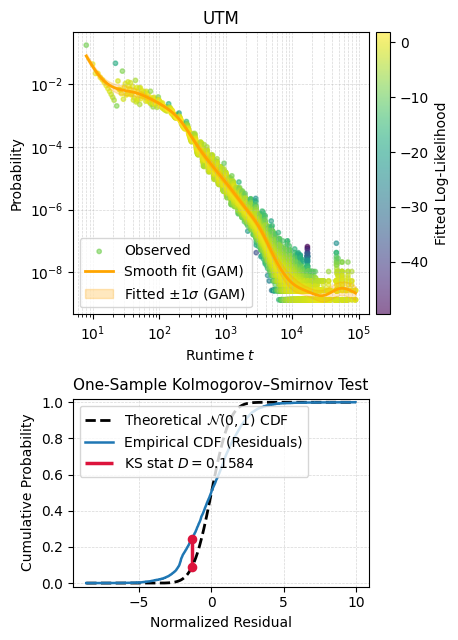

In [11]:
# ---------------------------------------------------------
# 1. Predictions & Point-wise Log-Likelihood
# ---------------------------------------------------------
log_rt = np.log(runtime)
log_p_obs = np.log(p)

mu_hat = gam_mu.predict(log_rt)
sigma_hat = np.sqrt(np.exp(gam_sigma.predict(log_rt)))

# Standardized residuals (z-scores under the model)
z = (log_p_obs - mu_hat) / sigma_hat

# Point-wise log-likelihood
point_log_lik = norm.logpdf(log_p_obs, loc=mu_hat, scale=sigma_hat)

# Smooth curve grid
x_plot = np.geomspace(runtime.min(), runtime.max(), 1000)
log_x_plot = np.log(x_plot)
mu_plot = gam_mu.predict(log_x_plot)
sigma_plot = np.sqrt(np.exp(gam_sigma.predict(log_x_plot)))

y_plot = np.exp(mu_plot)
y_lower = np.exp(mu_plot - sigma_plot)
y_upper = np.exp(mu_plot + sigma_plot)

# ---------------------------------------------------------
# 2. Kolmogorov-Smirnov Calculation
# ---------------------------------------------------------
# Run 1-sample KS test against standard normal N(0, 1)
ks_stat, ks_pval = stats.kstest(z, "norm")

# Sort residuals to construct ECDF
z_sorted = np.sort(z)
n = len(z_sorted)
ecdf_y = np.arange(1, n + 1) / n
ecdf_y_prev = np.arange(0, n) / n  # Lower step for exact supremum distance
cdf_theo = stats.norm.cdf(z_sorted)

# Find exact point of maximal absolute deviation D
diffs_high = np.abs(ecdf_y - cdf_theo)
diffs_low = np.abs(ecdf_y_prev - cdf_theo)
max_idx = np.argmax(np.maximum(diffs_high, diffs_low))

z_max = z_sorted[max_idx]
y_ecdf_max = ecdf_y[max_idx]
y_theo_max = stats.norm.cdf(z_max)

# ---------------------------------------------------------
# 3. Two-Panel Visualization
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), gridspec_kw={"height_ratios": [1.5, 1]}
)

# Panel 1: Runtime distribution + Likelihood coloring
scatter = ax1.scatter(
    runtime,
    p,
    c=point_log_lik,
    cmap="viridis",
    s=10,
    alpha=0.6,
    label="Observed",
    zorder=1,
)
ax1.plot(x_plot, y_plot, "-", linewidth=2, color="orange", label="Smooth fit (GAM)")
ax1.fill_between(
    x_plot, y_lower, y_upper, alpha=0.25, color="orange", label="Fitted $\pm 1\\sigma$ (GAM)"
)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Runtime $t$")
ax1.set_ylabel("Probability")
ax1.set_title(names_dict[domain])
ax1.grid(True, which="both", ls="--", linewidth=0.5)

# 1. Enforce explicit legend order: Observed first, then Smooth fit, then Fitted +-sigma
handles, labels = ax1.get_legend_handles_labels()
desired_order = ["Observed", "Smooth fit (GAM)", "Fitted $\pm 1\\sigma$ (GAM)"]
ordered_handles = [handles[labels.index(name)] for name in desired_order]
ax1.legend(ordered_handles, desired_order, loc="lower left")

# Panel 2: KS Test ECDF vs Theoretical Normal CDF
z_range = np.linspace(min(z_sorted.min(), -4), max(z_sorted.max(), 4), 500)
ax2.plot(
    z_range,
    stats.norm.cdf(z_range),
    "k--",
    linewidth=2,
    label="Theoretical $\\mathcal{N}(0, 1)$ CDF",
)
ax2.step(
    z_sorted,
    ecdf_y,
    where="post",
    color="#1f77b4",
    linewidth=1.8,
    label="Empirical CDF (Residuals)",
)

# Annotate KS statistic (max deviation line)
ax2.vlines(
    x=z_max,
    ymin=min(y_ecdf_max, y_theo_max),
    ymax=max(y_ecdf_max, y_theo_max),
    color="crimson",
    linewidth=2.5,
    label=f"KS stat $D = {ks_stat:.4f}$",
)
ax2.scatter(
    [z_max, z_max],
    [y_ecdf_max, y_theo_max],
    color="crimson",
    s=35,
    zorder=5,
)

ax2.set_xlabel("Normalized Residual")
ax2.set_ylabel("Cumulative Probability")
ax2.set_title("One-Sample Kolmogorov–Smirnov Test", size=11)
ax2.set_ylim(-0.02, 1.02)
ax2.grid(True, ls="--", linewidth=0.5)
ax2.legend(loc="upper left")

# Call tight_layout FIRST so subplots calculate their standard layout
plt.tight_layout()

# Add colorbar to ax1
cbar = fig.colorbar(scatter, ax=ax1, pad=0.02)
cbar.set_label("Fitted Log-Likelihood")

# 2. Match the horizontal bounds of ax2 to ax1 (excluding the colorbar)
pos1 = ax1.get_position()
pos2 = ax2.get_position()
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])

#fig.tight_layout()
#fig.savefig(f"spike_test_{domain}.pdf")

print(f"KS $p = {ks_pval:.2e}$")